## Vector Stores 
Vector Stores are Databases that are designed to store, manage, search through high dimensional vectors embeddings. 

In RAG, we need to:   
Get data --> Split data into chunks --> Generate Vector Embeddings --> Store them in Vector Store --> Take user query --> Generate vector of query --> Do semantic search to get vectors most similar to query (Retrieval)

Key Features: 
- Storage: Ensures that vectors and their associated metadata are retained. Storage can be any - on memory, or on-disk
- Similarity Searches: Vector stores help retrieve the vectors that are more similar to query vector
- Indexing: Indexing means organizing data in efficient manner so that searching is fast. For this we create a special data structure called "Index". In Vector Databases we have to organize vectors in such a way that semantic search is fast and efficient  
- CRUD Operations: We can perform CRUD Operations on vector stores

Use cases:
- RAG
- Recommendation Systems
- Semantic Search
- Image/Multimedia search

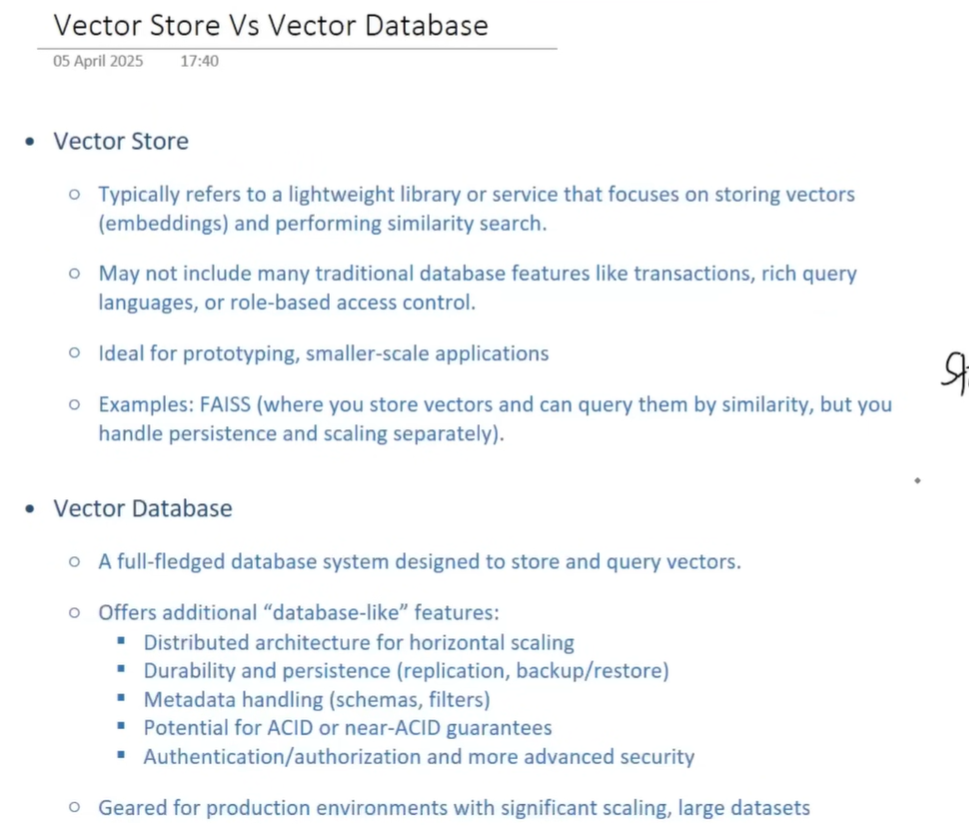

A Vector Database is bascially Vector Store with extra database features

### Vector Stores in Langchain
- Supported Stores : FAISS, Pinecone, Chroma, Qdrant etc...
- Common interface : Uniform API to use and vector store without much change in code
- Metadata Handling : Allows you to attach metadata to each document. Hence filter based retrieval is possible  

### Understanding Vector Stores with help of Chroma
Chroma is a light weight vector database, which is good for local development and small to medium scale production

Heirarchy:   
_Tenant (User) --> Databases (user can create multiple database) --> Collections (each database can have multiple collections (collection is something similar to tables in relational databases)) --> Document (each collection have multiple documents, document have the embedding and metadata)_

In [1]:
from langchain_huggingface import HuggingFaceEmbeddings
from dotenv import load_dotenv
from langchain_core.documents import Document
from langchain_chroma import Chroma

In [2]:
load_dotenv()
embedding_model = HuggingFaceEmbeddings(
    model = "sentence-transformers/all-MiniLM-L6-v2"
)

In [3]:
#docs 
doc1 = Document(
        page_content="Virat Kohli is one of the most successful and consistent batsmen in IPL history. Known for his aggressive batting style and fitness, he has led the Royal Challengers Bangalore in multiple seasons.",
        metadata={"team": "Royal Challengers Bangalore"}
    )
doc2 = Document(
        page_content="Rohit Sharma is the most successful captain in IPL history, leading Mumbai Indians to five titles. He's known for his calm demeanor and ability to play big innings under pressure.",
        metadata={"team": "Mumbai Indians"}
    )
doc3 = Document(
        page_content="MS Dhoni, famously known as Captain Cool, has led Chennai Super Kings to multiple IPL titles. His finishing skills, wicketkeeping, and leadership are legendary.",
        metadata={"team": "Chennai Super Kings"}
    )
doc4 = Document(
        page_content="Jasprit Bumrah is considered one of the best fast bowlers in T20 cricket. Playing for Mumbai Indians, he is known for his yorkers and death-over expertise.",
        metadata={"team": "Mumbai Indians"}
    )
doc5 = Document(
        page_content="Ravindra Jadeja is a dynamic all-rounder who contributes with both bat and ball. Representing Chennai Super Kings, his quick fielding and match-winning performances make him a key player.",
        metadata={"team": "Chennai Super Kings"}
    )

In [8]:
vector_store = Chroma(
    embedding_function=embedding_model,
    persist_directory="my_chroma_db",
    collection_name="sample"
)

docs = [doc1, doc2, doc3, doc4, doc5]

In [9]:
## Create (Add Documents)
vector_store.add_documents(docs)       #A random id for each doc will be given (we can also set these by ourself)

['a36ffee2-a11b-4326-8fa4-83caa2616baa',
 'be8fb5a3-81f1-4d13-8087-d7664c71cfcd',
 'b1c43381-969b-4f02-8dfc-babf1bc6b7c1',
 '700bf907-4370-4023-93ed-6a99393388d7',
 '11f33527-cb8e-41a7-a6ec-c6ed96b504f0']

In [19]:
## Retrieve 
vector_store.get(include=['embeddings', 'documents', 'metadatas'])

{'ids': ['a36ffee2-a11b-4326-8fa4-83caa2616baa',
  'be8fb5a3-81f1-4d13-8087-d7664c71cfcd',
  'b1c43381-969b-4f02-8dfc-babf1bc6b7c1',
  '700bf907-4370-4023-93ed-6a99393388d7',
  '11f33527-cb8e-41a7-a6ec-c6ed96b504f0'],
 'embeddings': array([[ 0.00994723,  0.06914331, -0.05147116, ..., -0.03543342,
          0.01284807,  0.01248291],
        [ 0.00127748,  0.0312985 , -0.02375381, ..., -0.00518365,
         -0.03280614,  0.02737715],
        [-0.10265913,  0.02650809,  0.02271503, ..., -0.03359754,
         -0.07984941, -0.0150771 ],
        [ 0.02123392, -0.02468549, -0.04494369, ..., -0.10995812,
          0.00572557,  0.09915378],
        [ 0.01873974,  0.04382847, -0.04304256, ..., -0.07801623,
         -0.07840683, -0.00304191]], shape=(5, 384)),
 'documents': ['Virat Kohli is one of the most successful and consistent batsmen in IPL history. Known for his aggressive batting style and fitness, he has led the Royal Challengers Bangalore in multiple seasons.',
  "Rohit Sharma is the mo

In [ ]:
## Semantic Search 
vector_store.similarity_search_with_relevance_scores(
    query="Who is virat kohli",
    k=1 # k = number of docs we want to retieve 
)

[(Document(id='a36ffee2-a11b-4326-8fa4-83caa2616baa', metadata={'team': 'Royal Challengers Bangalore'}, page_content='Virat Kohli is one of the most successful and consistent batsmen in IPL history. Known for his aggressive batting style and fitness, he has led the Royal Challengers Bangalore in multiple seasons.'),
  0.6938744580360353)]

In [21]:
## Metadata based filter
vector_store.similarity_search(
    query="",
    filter={'team':'Royal Challengers Bangalore'}
)

[Document(id='a36ffee2-a11b-4326-8fa4-83caa2616baa', metadata={'team': 'Royal Challengers Bangalore'}, page_content='Virat Kohli is one of the most successful and consistent batsmen in IPL history. Known for his aggressive batting style and fitness, he has led the Royal Challengers Bangalore in multiple seasons.')]

In [ ]:
## Update Documents
updated_doc1 = Document(
    page_content="Virat Kohli, the former captain of Royal Challengers Bangalore (RCB), is renowned for his aggressive leadership and consistent batting performances. He holds the record for the most runs in IPL history, including multiple centuries in a single season. Despite RCB not winning an IPL title under his captaincy, Kohli's passion and fitness set a benchmark for the league. His ability to chase targets and anchor innings has made him one of the most dependable players in T20 cricket.",
    metadata={"team": "Royal Challengers Bangalore"}
)

vector_store.update_document(document_id="a36ffee2-a11b-4326-8fa4-83caa2616baa",document=updated_doc1)

In [24]:
vector_store.get(ids="a36ffee2-a11b-4326-8fa4-83caa2616baa")

{'ids': ['a36ffee2-a11b-4326-8fa4-83caa2616baa'],
 'embeddings': None,
 'documents': ["Virat Kohli, the former captain of Royal Challengers Bangalore (RCB), is renowned for his aggressive leadership and consistent batting performances. He holds the record for the most runs in IPL history, including multiple centuries in a single season. Despite RCB not winning an IPL title under his captaincy, Kohli's passion and fitness set a benchmark for the league. His ability to chase targets and anchor innings has made him one of the most dependable players in T20 cricket."],
 'uris': None,
 'included': ['metadatas', 'documents'],
 'data': None,
 'metadatas': [{'team': 'Royal Challengers Bangalore'}]}

In [25]:
## Delete 
vector_store.delete(ids=['a36ffee2-a11b-4326-8fa4-83caa2616baa'])

In [26]:
## View documents
vector_store.get()

{'ids': ['be8fb5a3-81f1-4d13-8087-d7664c71cfcd',
  'b1c43381-969b-4f02-8dfc-babf1bc6b7c1',
  '700bf907-4370-4023-93ed-6a99393388d7',
  '11f33527-cb8e-41a7-a6ec-c6ed96b504f0'],
 'embeddings': None,
 'documents': ["Rohit Sharma is the most successful captain in IPL history, leading Mumbai Indians to five titles. He's known for his calm demeanor and ability to play big innings under pressure.",
  'MS Dhoni, famously known as Captain Cool, has led Chennai Super Kings to multiple IPL titles. His finishing skills, wicketkeeping, and leadership are legendary.',
  'Jasprit Bumrah is considered one of the best fast bowlers in T20 cricket. Playing for Mumbai Indians, he is known for his yorkers and death-over expertise.',
  'Ravindra Jadeja is a dynamic all-rounder who contributes with both bat and ball. Representing Chennai Super Kings, his quick fielding and match-winning performances make him a key player.'],
 'uris': None,
 'included': ['metadatas', 'documents'],
 'data': None,
 'metadatas':